# I validated nilearn conn matrix manually against individual timeseries labels and it checks out

In [9]:
import numpy as np
import os
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, Image, SVG
import pandas as pd
from matplotlib import rcParams
rcParams["path.simplify"] = True
rcParams["path.simplify_threshold"] = 0.5
# Set the font to Arial
rcParams['font.family'] = 'Arial'
rcParams['svg.fonttype'] = 'none'
from matplotlib.pyplot import colorbar
import matplotlib.patheffects as pe
from nilearn import plotting, connectome
from sympy import symbols, Eq, solve
from mne_connectivity.viz import plot_connectivity_circle
from mne.viz import circular_layout
import sys
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
sys.path.append("/Users/aeed/Dropbox/SCRIPTS/functional_connectivity")
from FC_functions import combine_list, average_csv_list, plot_pcolor_map, plot_unsym_conn_mat, reduce_conn_matrix, plot_connectivity_circle2,create_flattened_csv, plot_conn_rows, average_R_then_L_csv_list, plot_unsym_conn_mat, quadrant_means_to_2x2, quadrant_RMSE_to_2x2, reshape_R_then_L, average_R_then_L_csv_list, reshape_R_then_L_stats, plot_conn_matrix

# ================================PALM========================

In [2]:
# atlas labels
labels_ICA_list = ['Amygdala',
                   'ORB, OLF, PL, ACA',
                   'MO, SS',
                   'somatomotor',
                   'DMN'
                   ]

In [3]:
no_rois = len(labels_ICA_list)

In [21]:
labels_ICA_list

['Amygdala', 'ORB, OLF, PL, ACA', 'MO, SS', 'DMN']

In [22]:
%%bash
# session 1 vs session 2
orig_dir="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats"
rm -rf "${orig_dir}/partial_correlation"
for conn in ${orig_dir}/*correlation*; do
    #if [ -d "${conn}" ]; then
        conn=$(basename $conn)
        
        touch ${orig_dir}/${conn}/PBS_ses-01_${conn}.txt
        ls --color=never ${orig_dir}/${conn}/ses-01/PBS_*_ses-01_${conn}_mat_flat.csv > ${orig_dir}/${conn}/PBS_ses-01_${conn}.txt

        touch ${orig_dir}/${conn}/PFF_ses-01_${conn}.txt
        ls --color=never ${orig_dir}/${conn}/ses-01/PFF_*_ses-01_${conn}_mat_flat.csv > ${orig_dir}/${conn}/PFF_ses-01_${conn}.txt

    #fi
    
done

In [23]:
%%bash
# session 1 vs session 2
orig_dir="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats"
rm -rf "${orig_dir}/partial_correlation"
for conn in ${orig_dir}/*correlation*; do
    #if [ -d "${conn}" ]; then
        conn=$(basename $conn)

        touch ${orig_dir}/${conn}/PBS_ses-01_${conn}.txt
        ls --color=never ${orig_dir}/${conn}/ses-01/PBS_*_ses-01_${conn}_mat_flat.csv > ${orig_dir}/${conn}/PBS_${conn}.txt

        touch ${orig_dir}/${conn}/PFF_ses-01_${conn}.txt
        ls --color=never ${orig_dir}/${conn}/ses-01/PFF_*_ses-01_${conn}_mat_flat.csv > ${orig_dir}/${conn}/PFF_${conn}.txt

    #fi

done

In [4]:
# read the txt file, and get the number of lines and that will be the number of subjects
orig_dir="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats"
conn = "correlation"
PBS_file = f"{orig_dir}/{conn}/PBS_ses-01_{conn}.txt"
PFF_file = f"{orig_dir}/{conn}/PFF_ses-01_{conn}.txt"
with open(PBS_file, 'r') as f:
    lines = f.readlines()
    num_subjects = len(lines)
PBS_n_subjects = num_subjects

with open(PFF_file, 'r') as f:
    lines = f.readlines()
    num_subjects = len(lines)

PFF_n_subjects = num_subjects

# ++++++++++++++++++++++++++<font color="red"> Correlation</font>+++++++++++++++++++++++++++++++++++

In [5]:
PBS_s1_correlation = average_csv_list("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats/correlation/PBS_ses-01_correlation.txt")[0]

PFF_s1_correlation = average_csv_list("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats/correlation/PFF_ses-01_correlation.txt")[0]


# percentage change
# PBS_s2_vs_s1_correlation = (PBS_s2_correlation - PBS_s1_correlation) / ((PBS_s1_correlation)) * 100
# PFF_s2_vs_s1_correlation = (PFF_s2_correlation - PFF_s1_correlation) / ((PFF_s1_correlation)) * 100
#
#
#
# PBS_PFF_s1_correlation = (PBS_s1_correlation - PFF_s1_correlation) / ((PFF_s1_correlation)) * 100
# PBS_PFF_s2_correlation = (PBS_s2_correlation - PFF_s2_correlation) / ((PFF_s2_correlation)) * 100

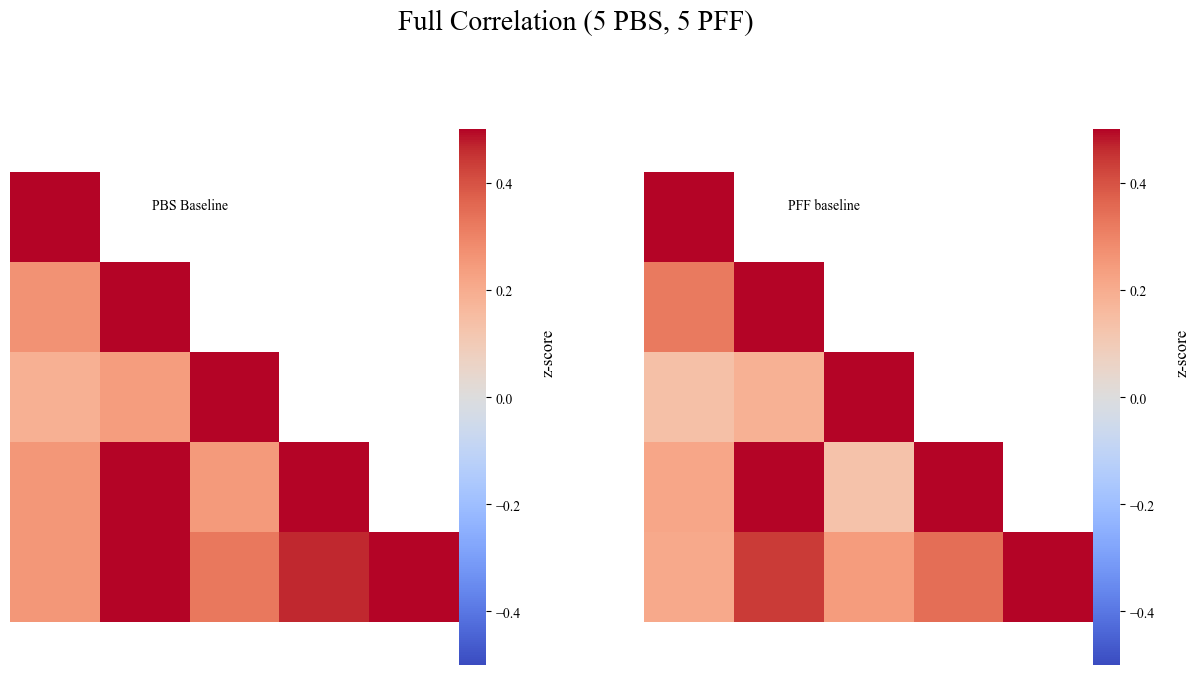

In [7]:
from nilearn import plotting

# create a six subplots figure
fig, axs = plt.subplots(1, 2, figsize=(15, 8))
# fig.suptitle('Apoe3 \n Concussed Baseline')
# plot the first subplot using plotting 
fig.suptitle(f' Full Correlation ({PBS_n_subjects} PBS, {PFF_n_subjects} PFF)', fontsize=20)
vmin_val = -0.5
vmax_val = 0.5


vmin_val_ch = -50
vmax_val_ch = +50

title_font = 10
title_y_pos = 0.9
title_x_pos = 0.4

cbar_x_pos = 6
cbar_y_pos = 2

# [0,0]
plot_conn_matrix(
    axs[0],
    PBS_s1_correlation,


    # labels=labels_ICA_list,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    # tri='lower',
    cmap='coolwarm',
    # auto_fit=True,

)
axs[0].set_title('PBS Baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[0].text(cbar_x_pos, cbar_y_pos,  'z-score', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')



# [0,2]
plot_conn_matrix(
    axs[1],
    PFF_s1_correlation,


    # labels=labels_ICA_list,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    # tri='lower',
    cmap='coolwarm',
    # auto_fit=True,

)
axs[1].set_title('PFF baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[1].text(cbar_x_pos, cbar_y_pos,  'z-score', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')




for ax in axs.flat:
    ax.grid(False)
    # remove the horizontal and vertical lines around the matrix
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)


# plt.subplots_adjust(left=0, right=1, bottom=0, top=0.9, wspace=0, hspace=0)


plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats/correlation/correlation.svg")
plt.show()

In [27]:

create_flattened_csv("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats/correlation/PBS_correlation.txt", "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats/correlation/PBS_correlation.csv")

create_flattened_csv("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats/correlation/PFF_correlation.txt", "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats/correlation/PFF_correlation.csv")

In [28]:
PBS_correlation_csv = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats/correlation/PBS_correlation.csv", delimiter=",")
PFF_correlation_csv = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats/correlation/PFF_correlation.csv", delimiter=",")

In [29]:
orig_dir = "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats"
# PBS
PBS_s1 = PBS_correlation_csv[:]
np.savetxt(f"{orig_dir}/correlation/PBS_s1.csv", PBS_s1, delimiter=",")


# PFF
PFF_s1 = PFF_correlation_csv[:]
np.savetxt(f"{orig_dir}/correlation/PFF_s1.csv", PFF_s1, delimiter=",")


In [30]:
PBS_vs_PFF = np.concatenate((PBS_s1, PFF_s1), axis=0)
np.savetxt(f"{orig_dir}/correlation/PBS_vs_PFF.csv", PBS_vs_PFF, delimiter=",")

In [31]:
%%bash
# palm concussion
orig_dir="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats"

design_PBS_vs_PFF="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/UNPAIRED_stats_design/5_vs_5.mat"
contrast_PBS_vs_PFF="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/UNPAIRED_stats_design/5_vs_5.con"
#EB_PBS_vs_PFF="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/UNPAIRED_stats_design/EB_9.mat"


sub_list="${orig_dir}/correlation/PBS_vs_PFF.csv"
output_dir="${orig_dir}/correlation"
palm -i $sub_list -d ${design_PBS_vs_PFF} -t ${contrast_PBS_vs_PFF}  -o ${output_dir}/PBS_vs_PFF -n 10000  -fdr -ise -ee -corrcon



             ___         ___                         ___
            /  /\       /  /\                       /__/\
           /  /::\     /  /::\                     |  |::\
          /  /:/\:\   /  /:/\:\    ___     ___     |  |:|:\
         /  /:/~/:/  /  /:/~/::\  /__/\   /  /\  __|__|:|\:\
        /__/:/ /:/  /__/:/ /:/\:\ \  \:\ /  /:/ /__/::::| \:\
        \  \:\/:/   \  \:\/:/__\/  \  \:\  /:/  \  \:\~~\__\/
         \  \::/     \  \::/        \  \:\/:/    \  \:\
          \  \:\      \  \:\         \  \::/      \  \:\
           \  \:\      \  \:\         \__\/        \  \:\
            \__\/       \__\/                       \__\/

                 Permutation Analysis of Linear Models
Running PALM alpha119 using MATLAB 9.11.0.1809720 (R2021b) Update 1 with the following options:
-i /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats/correlation/PBS_vs_PFF.csv
-d /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/UNPAIRED_stats_design

Error using exit
Unrecognized function or variable 'Settings'.
 
Error using exit
Unrecognized function or variable 'Settings'.
 


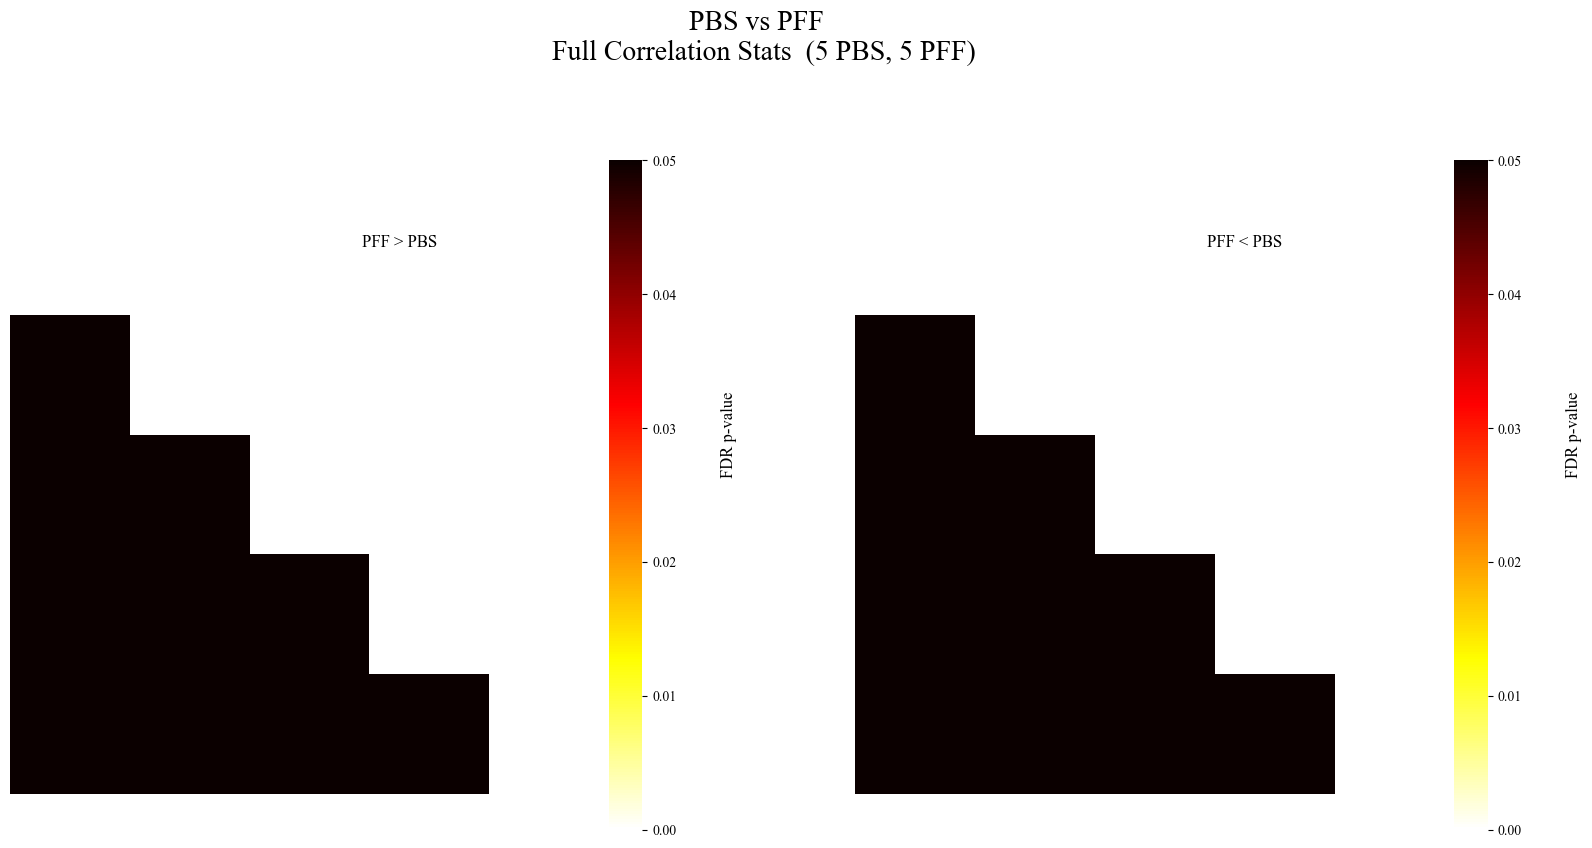

In [8]:

from nilearn import plotting
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle(f'PBS vs PFF \n Full Correlation Stats  ({PBS_n_subjects} PBS, {PFF_n_subjects} PFF)', fontsize=20)
vmin_val = 0
vmax_val = 0.05
title_font = 12
title_y_pos = 0.9
title_x_pos = 0.65

cbar_x_pos = 6
cbar_y_pos = 2

stat = "FDR"
cbar_legend = f"{stat} p-value"
stat_suffix = f"{stat.lower()}p"

# [0,0]
stats_PBS_VS_PFF_c2 = np.genfromtxt(f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats/correlation/PBS_vs_PFF_dat_tstat_{stat_suffix}_c2.csv", delimiter=",")
stats_PBS_VS_PFF_c2 = connectome.vec_to_sym_matrix(stats_PBS_VS_PFF_c2, diagonal=np.zeros(no_rois))

plot_conn_matrix(
    axs[0],
    stats_PBS_VS_PFF_c2,
    # labels=labels_ICA,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap='hot_r',

)
axs[0].set_title('PFF > PBS', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[0].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

# # [1,0]
stats_PBS_VS_PFF_c1 = np.genfromtxt(f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats/correlation/PBS_VS_PFF_dat_tstat_{stat_suffix}_c1.csv", delimiter=",")
stats_PBS_VS_PFF_c1 = connectome.vec_to_sym_matrix(stats_PBS_VS_PFF_c1, diagonal=np.zeros(no_rois))

plot_conn_matrix(
    axs[1],
    stats_PBS_VS_PFF_c1,
    # labels=labels_ICA,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap='hot_r',

)
axs[1].set_title('PFF < PBS', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[1].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')


for ax in axs.flat:
    ax.grid(False)
    # remove the horizontal and vertical lines around the matrix
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
#     
#     ax.hlines(y=22.58, xmin=0, xmax=2, colors="khaki", linewidth=7, label="Olfactory", antialiased=True)
#     ax.hlines(y=22.58, xmin=2, xmax=4, colors="navy", linewidth=7, label="Isocortex", antialiased=True)
#     ax.hlines(y=22.58, xmin=4, xmax=6, colors="green", linewidth=7, label="Hipp formation", antialiased=True)
#     ax.hlines(y=22.58, xmin=6, xmax=8, colors="purple", linewidth=7,label="Amygdala", antialiased=True)
#     ax.hlines(y=22.58, xmin=8, xmax=10, colors="orange", linewidth=7, label="Striatum", antialiased=True)
#     ax.hlines(y=22.58, xmin=10, xmax=12, colors="brown", linewidth=7, label="Pallidum", antialiased=True)
#     ax.hlines(y=22.58, xmin=12, xmax=14, colors="pink", linewidth=7, label="Thalamus", antialiased=True)
#     ax.hlines(y=22.58, xmin=14, xmax=16, colors="gray", linewidth=7, label="Hypothalamus", antialiased=True)
#     ax.hlines(y=22.58, xmin=16, xmax=18, colors="cyan", linewidth=7, label="Midbrain", antialiased=True)
#     ax.hlines(y=22.58, xmin=18, xmax=20, colors="magenta", linewidth=7, label="Hindbrain", antialiased=True)
#     ax.hlines(y=22.58, xmin=20, xmax=22, colors="lime", linewidth=7, label="Cerebellum", antialiased=True)
# # 
#     ax.vlines(x=-0.58, ymin=0, ymax=2, colors="khaki", linewidth=7, antialiased=True)
#     ax.vlines(x=-0.58, ymin=2, ymax=4, colors="navy", linewidth=7, antialiased=True)
#     ax.vlines(x=-0.58, ymin=4, ymax=6, colors="green", linewidth=7, antialiased=True)
#     ax.vlines(x=-0.58, ymin=6, ymax=8, colors="purple", linewidth=7, antialiased=True)
#     ax.vlines(x=-0.58, ymin=8, ymax=10, colors="orange", linewidth=7, antialiased=True)
#     ax.vlines(x=-0.58, ymin=10, ymax=12, colors="brown", linewidth=7, antialiased=True)
#     ax.vlines(x=-0.58, ymin=12, ymax=14, colors="pink", linewidth=7, antialiased=True)
#     ax.vlines(x=-0.58, ymin=14, ymax=16, colors="gray", linewidth=7, antialiased=True)
#     ax.vlines(x=-0.58, ymin=16, ymax=18, colors="cyan", linewidth=7, antialiased=True)
#     ax.vlines(x=-0.58, ymin=18, ymax=20, colors="magenta", linewidth=7, antialiased=True)
#     ax.vlines(x=-0.58, ymin=20, ymax=22, colors="lime", linewidth=7, antialiased=True)
# ax.legend(loc='center', bbox_to_anchor=(1.6, 1.1))
# ax.text(-42,-12, "PBS", fontsize=20, rotation=90)
# ax.text(-42,15, "PFF", fontsize=20, rotation=90)


# ax.text(-17,27, "corrected for sex", fontsize=20, rotation=0)
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_ICA/FC_ICA_atlas_stats/correlation/Correlation_stats_{stat_suffix}.svg")
plt.show()